# Two-sided Over/Under 2.5 market-efficiency analysis

## Exploratory extension of the selected market-anchored model

**Research question.** Does the pooled market-anchored model identify stable mispricing on the Under 2.5 side as well as on the previously studied Over 2.5 side?

This notebook keeps the selected model fixed: pooled logistic regression, `L2 = 100`, a two-season rolling training window, and the model strategy's fixed EV threshold. The extension is exploratory because Under 2.5 is added after the Over-only research. Therefore the notebook reports Over, Under, and the combined rule transparently; it does not retrospectively choose the historically best side.

**Important interpretation.** This is still a market-anchored probability model. The signal probability uses the model probability, which includes no-vig average market log-odds plus team-form features. The execution test asks whether that calibrated probability finds value at specific quoted prices.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from football_edge.backtest import (
    build_research_dataset,
    run_pooled_rolling_walk_forward,
)
from football_edge.config import MINIMUM_EXPECTED_VALUE, RAW_DATA_DIR
from football_edge.data import discover_datasets
from football_edge.staking import cluster_bootstrap_roi
from football_edge.two_sided import (
    build_two_sided_candidates,
    select_two_sided_bets,
    summarize_two_sided_bets,
)

pd.set_option("display.max_columns", 40)
plt.style.use("seaborn-v0_8-whitegrid")

MODEL_NAME = "Pooled L2 = 100"
SELECTED_L2 = 100.0
TRAINING_WINDOW = 2
EV_THRESHOLD = MINIMUM_EXPECTED_VALUE
BOOTSTRAP_REPLICATIONS = 5_000
RANDOM_SEED = 42

SOURCE_ORDER = [
    "bet365",
    "pinnacle",
    "betfair_exchange",
    "average_preclosing",
    "best_preclosing",
    "best_closing",
]
SOURCE_LABELS = {
    "bet365": "Bet365",
    "pinnacle": "Pinnacle",
    "betfair_exchange": "Betfair Exchange",
    "average_preclosing": "Market average",
    "best_preclosing": "Market maximum",
    "best_closing": "Closing maximum*",
}
SIDE_ORDER = ["over", "under"]
SIDE_LABELS = {"over": "Over", "under": "Under"}
SIDE_COLORS = {"over": "#D95F02", "under": "#1B9E77"}
POLICY_ORDER = ["over_only", "under_only", "best_side"]
POLICY_COLORS = {
    "over_only": "#D95F02",
    "under_only": "#1B9E77",
    "best_side": "#7570B3",
}
POLICY_LABELS = {
    "over_only": "Over only",
    "under_only": "Under only",
    "best_side": "Higher-EV side",
}


def ordered_source_frame(frame: pd.DataFrame, source_column: str = "execution_source") -> pd.DataFrame:
    ordered = frame.copy()
    ordered[source_column] = pd.Categorical(
        ordered[source_column], categories=SOURCE_ORDER, ordered=True
    )
    return ordered.sort_values(source_column)


def set_panel_title(axis, source: str) -> None:
    axis.set_title(SOURCE_LABELS[source], fontsize=11, pad=8)


def add_zero_line(axis, *, vertical: bool = False) -> None:
    if vertical:
        axis.axvline(0, color="black", linewidth=1, alpha=0.8)
    else:
        axis.axhline(0, color="black", linewidth=1, alpha=0.8)


def symmetric_limits(values, padding: float = 0.15) -> tuple[float, float]:
    values = pd.Series(values).replace([np.inf, -np.inf], np.nan).dropna()
    if values.empty:
        return (-1.0, 1.0)
    max_abs = max(abs(values.min()), abs(values.max()))
    max_abs = max(max_abs * (1 + padding), 1.0)
    return (-max_abs, max_abs)

## 1. Research design

The model estimates the probability of Over 2.5 goals:

$$
p_{O,i}=\hat p_{model,i}
$$

The Under probability is the complement:

$$
p_{U,i}=1-\hat p_{model,i}
$$

For match $i$, side $s \in \{O,U\}$, and decimal execution odds $q_{i,s}$, the expected value of a one-unit stake is:

$$
EV_{i,s}=p_{i,s}q_{i,s}-1
$$

A bet qualifies when:

$$
EV_{i,s}\geq \tau, \qquad \tau = 3\%
$$

Three fixed policies are compared:

1. **Over only:** select Over when its EV is at least 3%.
2. **Under only:** select Under when its EV is at least 3%.
3. **Higher-EV side:** if either side qualifies, select at most one bet ? the qualifying side with higher estimated EV.

If both sides qualify for the same match and execution source, the observation is flagged. With synchronized internally consistent quotes this should be rare; it can indicate price timing, stale quotes, or market-aggregation artifacts. Closing maximum is retained only as a non-executable sensitivity.

In [2]:
datasets = discover_datasets(RAW_DATA_DIR)
all_matches = build_research_dataset(datasets)
predictions, coefficients = run_pooled_rolling_walk_forward(
    all_matches,
    l2=SELECTED_L2,
    model_name=MODEL_NAME,
    training_window=TRAINING_WINDOW,
)

sample_design = (
    predictions.groupby("season", sort=True)
    .agg(
        predictions=("date", "size"),
        leagues=("league", "nunique"),
        train_end=("train_end_date", "first"),
        test_start=("test_start_date", "first"),
        training_seasons=("training_seasons", "first"),
    )
    .reset_index()
)
assert (predictions["train_end_date"] < predictions["test_start_date"]).all()
assert predictions["model_probability"].between(0, 1).all()
sample_design

,season,predictions,leagues,train_end,test_start,training_seasons
0,23_24,1407,4,2023-06-04 20:00:00,2023-08-18 18:30:00,"21_22,22_23"
1,24_25,1407,4,2024-06-02 17:00:00,2024-08-23 18:00:00,"22_23,23_24"
2,25_26,1407,4,2025-05-25 20:00:00,2025-08-22 20:00:00,"23_24,24_25"


## 2. Two-sided candidate construction

Each side uses its own quoted price and its corresponding side-specific closing price. Missing closing odds reduce CLV coverage but never determine whether a pre-closing candidate or bet is included.

The construction also checks that Over and Under probabilities are complements for every match-source pair. This is important because the two sides are derived from one Over probability model, not from two independently fitted models.

In [3]:
candidates = build_two_sided_candidates(
    predictions,
    probability_column="model_probability",
    include_closing_maximum=True,
)

probability_check = (
    candidates.pivot_table(
        index=["execution_source", "match_row_id"],
        columns="bet_side",
        values="signal_probability",
        aggfunc="first",
    )
    .dropna(subset=["over", "under"])
    .assign(total_probability=lambda frame: frame["over"] + frame["under"])
)
assert np.allclose(probability_check["total_probability"], 1.0)

policy_bets = {
    policy: select_two_sided_bets(
        candidates,
        minimum_expected_value=EV_THRESHOLD,
        policy=policy,
    )
    for policy in POLICY_ORDER
}
over_bets = policy_bets["over_only"]
under_bets = policy_bets["under_only"]
best_side_bets = policy_bets["best_side"]

conflicts = (
    best_side_bets.loc[best_side_bets["both_sides_qualify"]]
    [["execution_source", "match_row_id", "league", "season", "date"]]
    .drop_duplicates(["execution_source", "match_row_id"])
    .sort_values(["execution_source", "date"])
)

print(f"Model EV threshold: {EV_THRESHOLD:.1%}")
print(f"Predicted matches: {len(predictions):,}")
print(f"Candidate rows: {len(candidates):,}")
print(f"Source-match conflicts where both sides qualify: {len(conflicts):,}")
conflicts

Model EV threshold: 3.0%
Predicted matches: 4,221
Candidate rows: 46,138
Source-match conflicts where both sides qualify: 2


,execution_source,match_row_id,league,season,date
203,best_closing,1098,Serie A,23_24,2023-10-06 19:45:00
2858,best_preclosing,3923,Serie A,25_26,2025-10-29 17:30:00


## 3. Number of selected bets and side mix

Counts come before returns because sparse strategies cannot support strong economic conclusions. The chart uses the **higher-EV-side** policy, so each execution source can contribute at most one selected side per match.

The closing maximum series is marked with an asterisk because it is a non-executable sensitivity: it assumes access to the best closing price in the dataset.

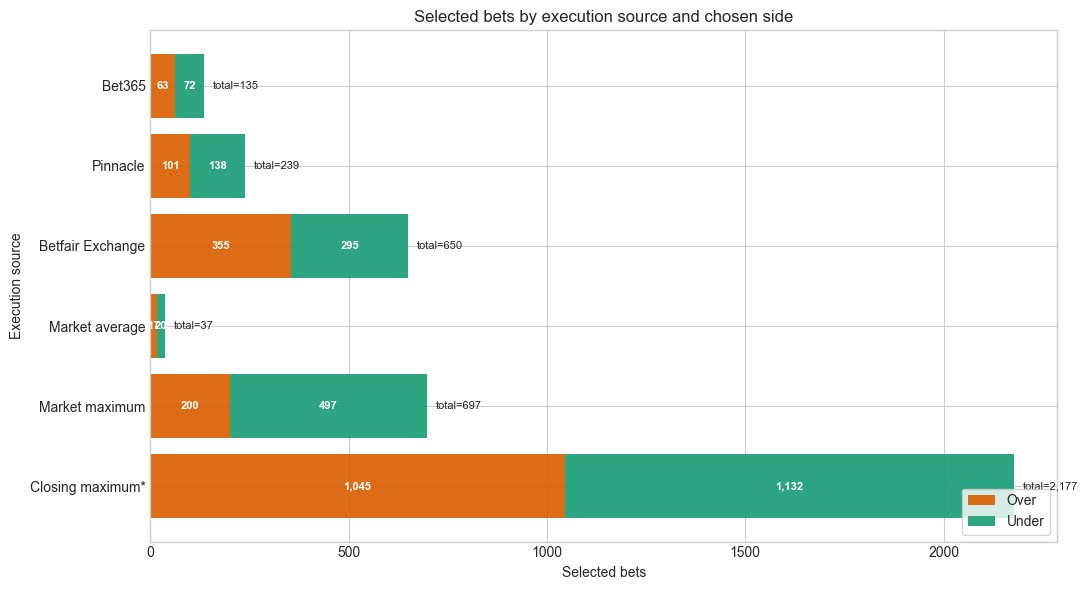

In [4]:
side_counts = (
    best_side_bets.groupby(["execution_source", "bet_side"], sort=True)
    .size()
    .unstack(fill_value=0)
    .reindex(index=SOURCE_ORDER, columns=SIDE_ORDER, fill_value=0)
)

y = np.arange(len(side_counts))
figure, axis = plt.subplots(figsize=(11, 6))
left = np.zeros(len(side_counts))
for side in SIDE_ORDER:
    values = side_counts[side].to_numpy()
    bars = axis.barh(
        y,
        values,
        left=left,
        label=SIDE_LABELS[side],
        color=SIDE_COLORS[side],
        alpha=0.92,
    )
    for bar, value in zip(bars, values):
        if value > 0:
            axis.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_y() + bar.get_height() / 2,
                f"{int(value):,}",
                ha="center",
                va="center",
                color="white",
                fontsize=8,
                fontweight="bold",
            )
    left += values

for total, ypos in zip(side_counts.sum(axis=1), y):
    axis.text(total + max(side_counts.sum(axis=1).max() * 0.01, 1), ypos, f"total={int(total):,}", va="center", fontsize=8)

axis.set_yticks(y, [SOURCE_LABELS[source] for source in side_counts.index])
axis.invert_yaxis()
axis.set(
    title="Selected bets by execution source and chosen side",
    xlabel="Selected bets",
    ylabel="Execution source",
)
axis.legend(loc="lower right", frameon=True)
figure.tight_layout()
plt.show()

## 4. Side-specific flat-stake performance

Over-only and Under-only strategies are evaluated independently using one-unit stakes. Date-cluster bootstrap intervals preserve some same-day dependence. Intervals are suppressed below 30 date clusters.

Point estimates should be read together with sample size, uncertainty intervals, and CLV. A positive ROI with few bets or negative CLV is weak evidence of a tradable edge.

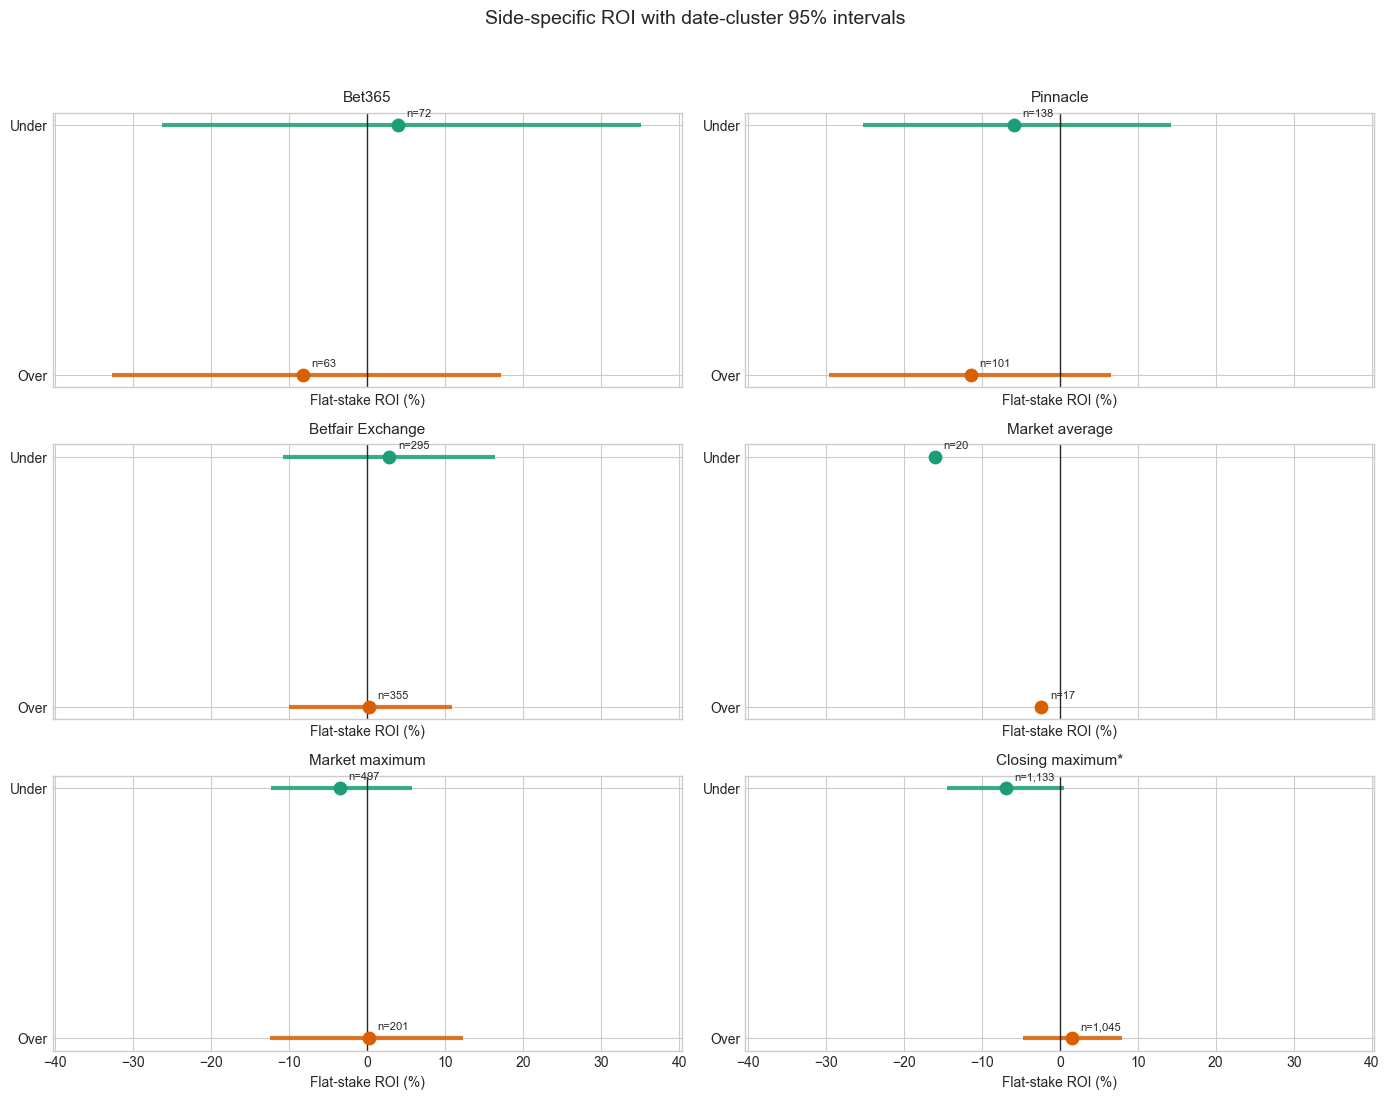

,execution_source,bet_side,bets,wins,win_rate_pct,average_odds,profit_units,roi_pct,mean_clv_pct,max_drawdown_units,date_clusters,sufficient_clusters_for_inference,roi_95_low_pct,roi_95_high_pct
0,average_preclosing,over,17,9,52.941176,1.864118,-0.40,-2.352941,-0.459527,4.21,15,False,NaN,NaN
1,average_preclosing,under,20,7,35.000000,2.402500,-3.20,-16.000000,-1.248818,6.06,20,False,NaN,NaN
2,best_closing,over,1045,516,49.377990,2.128249,16.58,1.586603,NaN,30.72,353,True,-4.720186,8.035888
3,best_closing,under,1133,448,39.541041,2.530609,-78.03,-6.887026,NaN,96.25,364,True,-14.425037,0.597904
4,best_preclosing,over,201,110,54.726368,1.875970,0.35,0.174129,-1.062825,14.96,134,True,-12.531866,12.289510
5,best_preclosing,under,497,227,45.674044,2.242575,-17.22,-3.464789,-0.752401,37.19,248,True,-12.335553,5.772360
6,bet365,over,63,30,47.619048,1.938254,-5.17,-8.206349,-0.005491,9.30,53,True,-32.789183,17.107926
7,bet365,under,72,30,41.666667,2.402917,2.87,3.986111,-0.107554,17.16,61,True,-26.343504,35.078217
8,betfair_exchange,over,355,188,52.957746,1.936282,0.84,0.236620,-0.966978,15.75,180,True,-10.009577,10.850207
9,betfair_exchange,under,295,134,45.423729,2.356339,8.38,2.840678,-1.347783,24.63,168,True,-10.815734,16.422140


In [5]:
side_bets = pd.concat([over_bets, under_bets], ignore_index=True)
side_summary = summarize_two_sided_bets(
    side_bets, ["execution_source", "bet_side"]
)

bootstrap_input = side_bets.copy()
bootstrap_input["source"] = bootstrap_input["execution_source"]
bootstrap_input["execution_source"] = (
    bootstrap_input["source"] + " | " + bootstrap_input["bet_side"]
)
side_bootstrap = cluster_bootstrap_roi(
    bootstrap_input,
    n_bootstrap=BOOTSTRAP_REPLICATIONS,
    random_seed=RANDOM_SEED,
)
side_bootstrap[["source", "bet_side"]] = side_bootstrap[
    "execution_source"
].str.split(" | ", regex=False, expand=True)
side_performance = side_summary.drop(
    columns=["roi_95_low_pct", "roi_95_high_pct"]
).merge(
    side_bootstrap[
        [
            "source",
            "bet_side",
            "date_clusters",
            "sufficient_clusters_for_inference",
            "roi_95_low_pct",
            "roi_95_high_pct",
        ]
    ],
    left_on=["execution_source", "bet_side"],
    right_on=["source", "bet_side"],
    how="left",
).drop(columns="source")

x_limits = symmetric_limits(
    pd.concat(
        [
            side_performance["roi_pct"],
            side_performance["roi_95_low_pct"],
            side_performance["roi_95_high_pct"],
        ]
    )
)
figure, axes = plt.subplots(3, 2, figsize=(14, 11), sharex=True)
axes = axes.ravel()
for axis, source in zip(axes, SOURCE_ORDER):
    subset = (
        side_performance.loc[side_performance["execution_source"].eq(source)]
        .set_index("bet_side")
        .reindex(SIDE_ORDER)
    )
    for position, side in enumerate(SIDE_ORDER):
        if side not in subset.index or pd.isna(subset.loc[side, "roi_pct"]):
            continue
        row = subset.loc[side]
        axis.scatter(row["roi_pct"], position, s=80, color=SIDE_COLORS[side], zorder=3)
        if pd.notna(row["roi_95_low_pct"]) and pd.notna(row["roi_95_high_pct"]):
            axis.hlines(
                position,
                row["roi_95_low_pct"],
                row["roi_95_high_pct"],
                color=SIDE_COLORS[side],
                linewidth=3,
                alpha=0.85,
            )
        axis.annotate(
            f"n={int(row['bets']):,}",
            (row["roi_pct"], position),
            xytext=(6, 6),
            textcoords="offset points",
            fontsize=8,
        )
    add_zero_line(axis, vertical=True)
    axis.set_xlim(x_limits)
    axis.set_yticks([0, 1], ["Over", "Under"])
    set_panel_title(axis, source)
    axis.set_xlabel("Flat-stake ROI (%)")

figure.suptitle("Side-specific ROI with date-cluster 95% intervals", y=0.995, fontsize=14)
figure.tight_layout(rect=[0, 0, 1, 0.965])
plt.show()

side_performance.sort_values(["execution_source", "bet_side"])

## 5. Closing-line value by side

Positive CLV means the selected quote was better than its side-specific closing quote:

$$
CLV = \left(\frac{q_{entry}}{q_{close}}-1\right)\times 100
$$

Closing maximum has no later benchmark and is therefore omitted. Persistent negative CLV weakens an apparently profitable ROI result because it suggests the strategy is not beating the subsequent market price.

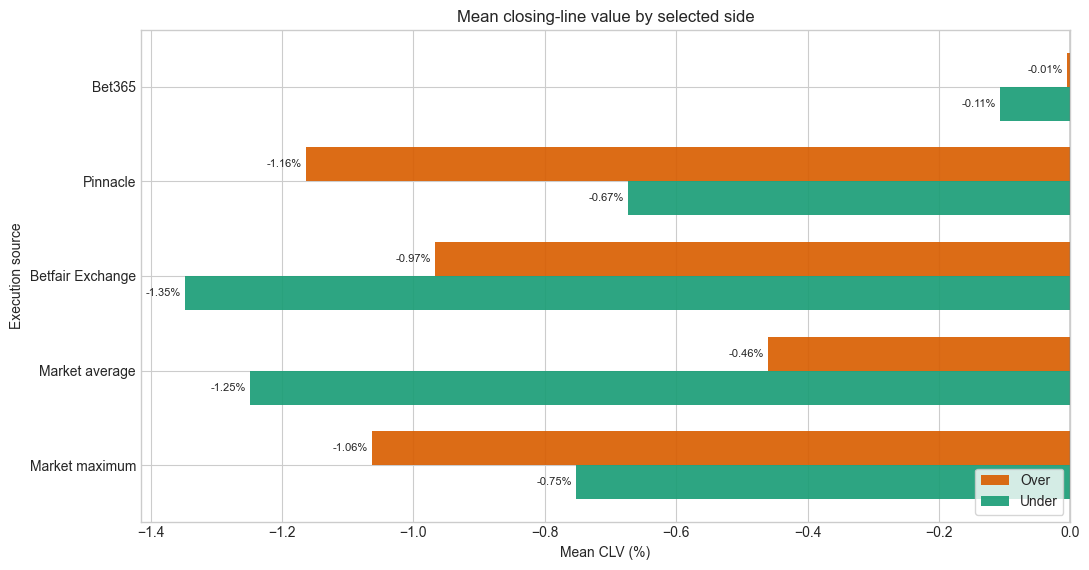

In [6]:
clv_data = side_performance.loc[
    side_performance["execution_source"].ne("best_closing")
].copy()
clv_pivot = (
    clv_data.pivot(index="execution_source", columns="bet_side", values="mean_clv_pct")
    .reindex([source for source in SOURCE_ORDER if source != "best_closing"])
)

y = np.arange(len(clv_pivot))
figure, axis = plt.subplots(figsize=(11, 5.8))
height = 0.36
for offset, side in [(-height / 2, "over"), (height / 2, "under")]:
    values = clv_pivot[side]
    bars = axis.barh(
        y + offset,
        values,
        height,
        label=SIDE_LABELS[side],
        color=SIDE_COLORS[side],
        alpha=0.92,
    )
    axis.bar_label(bars, labels=[f"{value:.2f}%" if pd.notna(value) else "" for value in values], padding=3, fontsize=8)
add_zero_line(axis, vertical=True)
axis.set_yticks(y, [SOURCE_LABELS[source] for source in clv_pivot.index])
axis.invert_yaxis()
axis.set(
    title="Mean closing-line value by selected side",
    xlabel="Mean CLV (%)",
    ylabel="Execution source",
)
axis.legend(loc="lower right", frameon=True)
figure.tight_layout()
plt.show()

## 6. Policy comparison

The combined policy is not allowed to place both Over and Under on the same source-match. It selects the qualifying side with higher estimated EV. Over-only and Under-only remain visible so the combined result cannot conceal side asymmetry.

This comparison is descriptive, not a new parameter search. The policies are fixed before looking at the plotted outcomes.

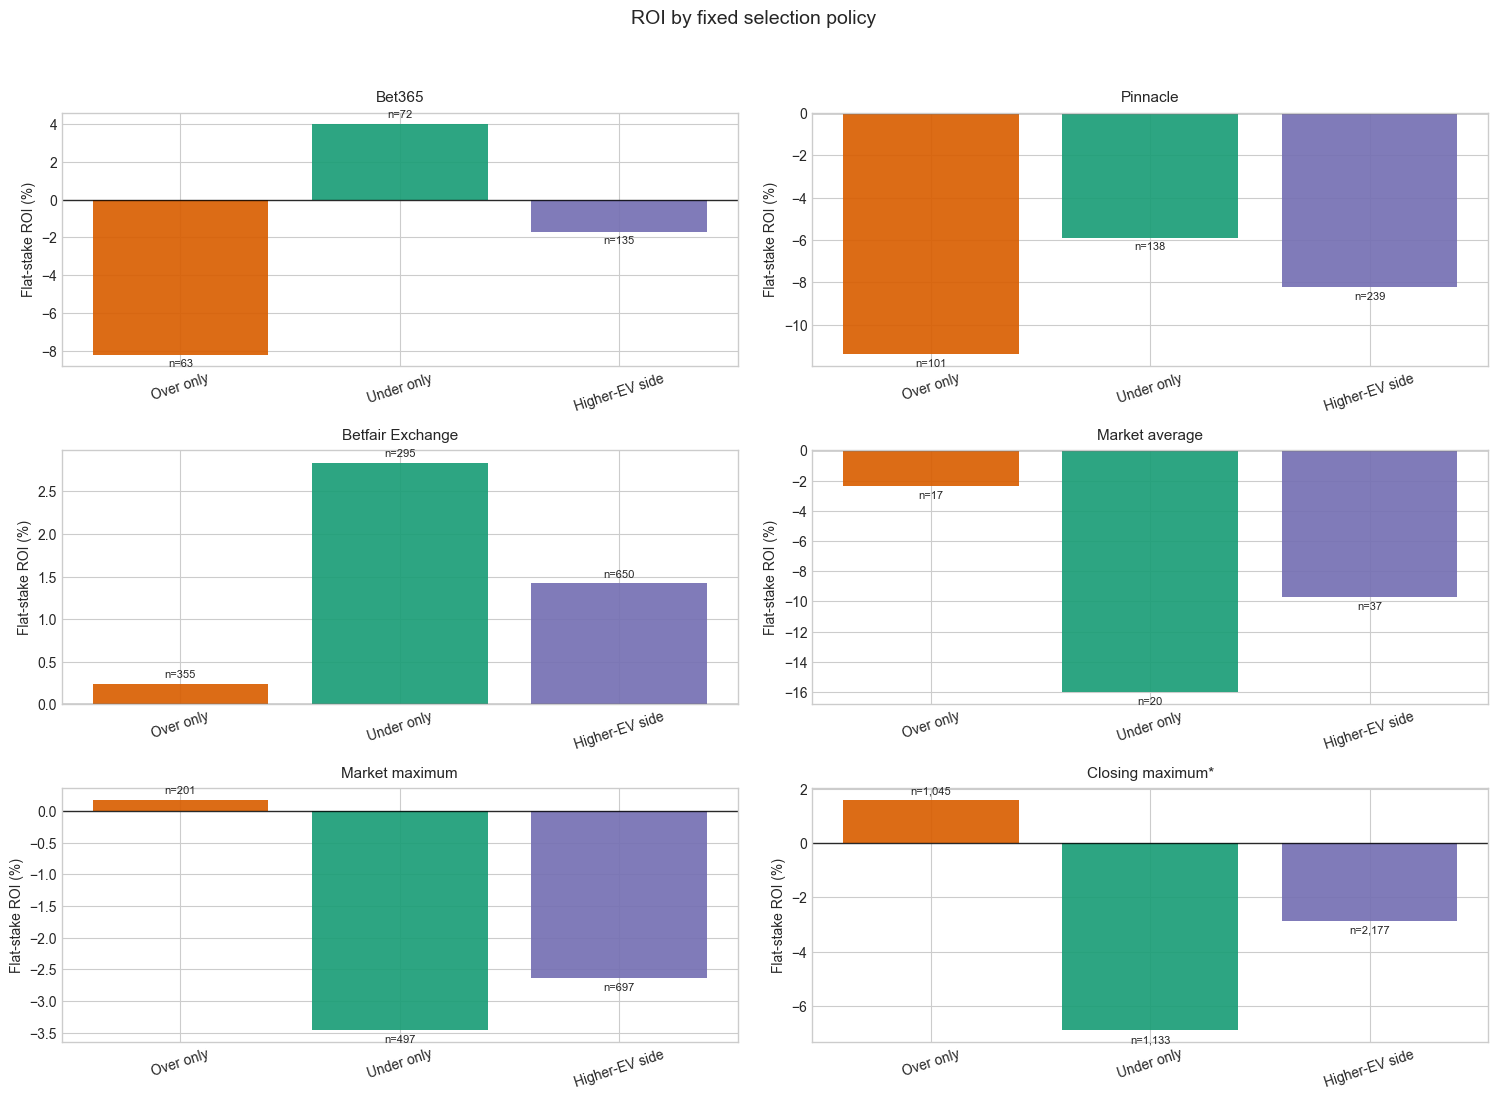

,execution_source,selection_policy,bets,wins,win_rate_pct,average_odds,profit_units,roi_pct,roi_95_low_pct,roi_95_high_pct,mean_clv_pct,max_drawdown_units
0,average_preclosing,best_side,37,16,43.243243,2.155135,-3.60,-9.729730,-44.974941,25.515481,-0.886171,8.24
1,average_preclosing,over_only,17,9,52.941176,1.864118,-0.40,-2.352941,-48.532355,43.826473,-0.459527,4.21
2,average_preclosing,under_only,20,7,35.000000,2.402500,-3.20,-16.000000,-69.014858,37.014858,-1.248818,6.06
3,best_closing,best_side,2177,963,44.235186,2.337662,-62.56,-2.873679,-7.715341,1.967982,NaN,100.17
4,best_closing,over_only,1045,516,49.377990,2.128249,16.58,1.586603,-4.924183,8.097389,NaN,30.72
5,best_closing,under_only,1133,448,39.541041,2.530609,-78.03,-6.887026,-13.989552,0.215501,NaN,96.25
6,best_preclosing,best_side,697,336,48.206600,2.136485,-18.37,-2.635581,-10.483941,5.212779,-0.858942,37.61
7,best_preclosing,over_only,201,110,54.726368,1.875970,0.35,0.174129,-12.772507,13.120766,-1.062825,14.96
8,best_preclosing,under_only,497,227,45.674044,2.242575,-17.22,-3.464789,-13.171261,6.241683,-0.752401,37.19
9,bet365,best_side,135,60,44.444444,2.186074,-2.30,-1.703704,-21.462849,18.055441,-0.059925,21.51


In [7]:
all_policy_bets = pd.concat(policy_bets.values(), ignore_index=True)
policy_summary = summarize_two_sided_bets(
    all_policy_bets, ["execution_source", "selection_policy"]
)

figure, axes = plt.subplots(3, 2, figsize=(15, 11), sharex=False)
axes = axes.ravel()
for axis, source in zip(axes, SOURCE_ORDER):
    subset = (
        policy_summary.loc[policy_summary["execution_source"].eq(source)]
        .set_index("selection_policy")
        .reindex(POLICY_ORDER)
        .reset_index()
    )
    labels = [POLICY_LABELS[policy] for policy in subset["selection_policy"]]
    colors = [POLICY_COLORS[policy] for policy in subset["selection_policy"]]
    bars = axis.bar(labels, subset["roi_pct"], color=colors, alpha=0.92)
    add_zero_line(axis)
    axis.bar_label(
        bars,
        labels=["" if pd.isna(value) else f"n={int(value):,}" for value in subset["bets"]],
        padding=3,
        fontsize=8,
    )
    set_panel_title(axis, source)
    axis.set_ylabel("Flat-stake ROI (%)")
    axis.tick_params(axis="x", rotation=18)

figure.suptitle("ROI by fixed selection policy", y=0.995, fontsize=14)
figure.tight_layout(rect=[0, 0, 1, 0.965])
plt.show()

policy_summary.sort_values(["execution_source", "selection_policy"])

### Cumulative profit paths

The paths reveal whether aggregate performance is persistent or concentrated in a short interval. Each panel has its own y-axis because coverage differs across execution sources. A shared legend is used to avoid covering the data.

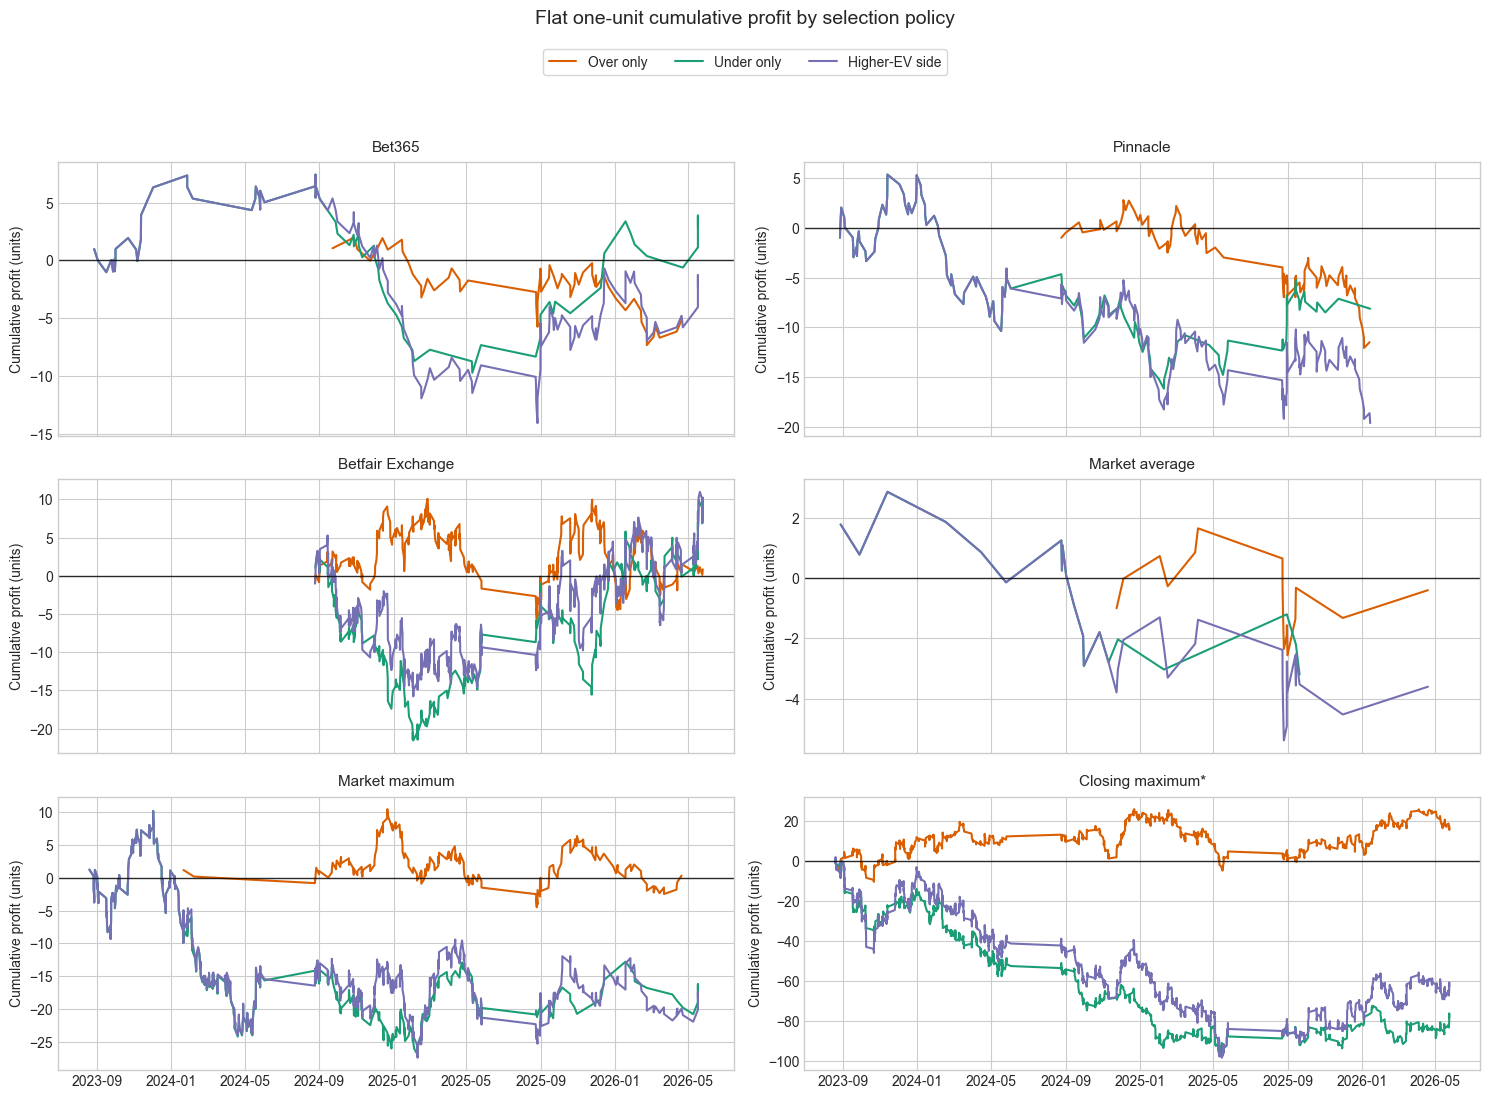

In [8]:
figure, axes = plt.subplots(3, 2, figsize=(15, 11), sharex=True)
axes = axes.ravel()
handles, labels = [], []
for axis, source in zip(axes, SOURCE_ORDER):
    for policy, bets in policy_bets.items():
        path = bets.loc[bets["execution_source"].eq(source)].sort_values(
            "date", kind="stable"
        ).copy()
        if path.empty:
            continue
        path["cumulative_profit"] = path["profit"].cumsum()
        line = axis.plot(
            path["date"],
            path["cumulative_profit"],
            label=POLICY_LABELS[policy],
            color=POLICY_COLORS[policy],
            linewidth=1.5,
        )[0]
        if POLICY_LABELS[policy] not in labels:
            handles.append(line)
            labels.append(POLICY_LABELS[policy])
    add_zero_line(axis)
    set_panel_title(axis, source)
    axis.set_ylabel("Cumulative profit (units)")

figure.legend(handles, labels, loc="upper center", ncol=3, frameon=True, bbox_to_anchor=(0.5, 0.965))
figure.suptitle("Flat one-unit cumulative profit by selection policy", y=0.995, fontsize=14)
figure.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

## 7. Seasonal stability of the higher-EV-side policy

A viable edge should not depend on one season. Bars show combined-policy ROI; labels report total bets and the Over/Under mix. Blank early Betfair periods reflect unavailable quotes rather than zero returns.

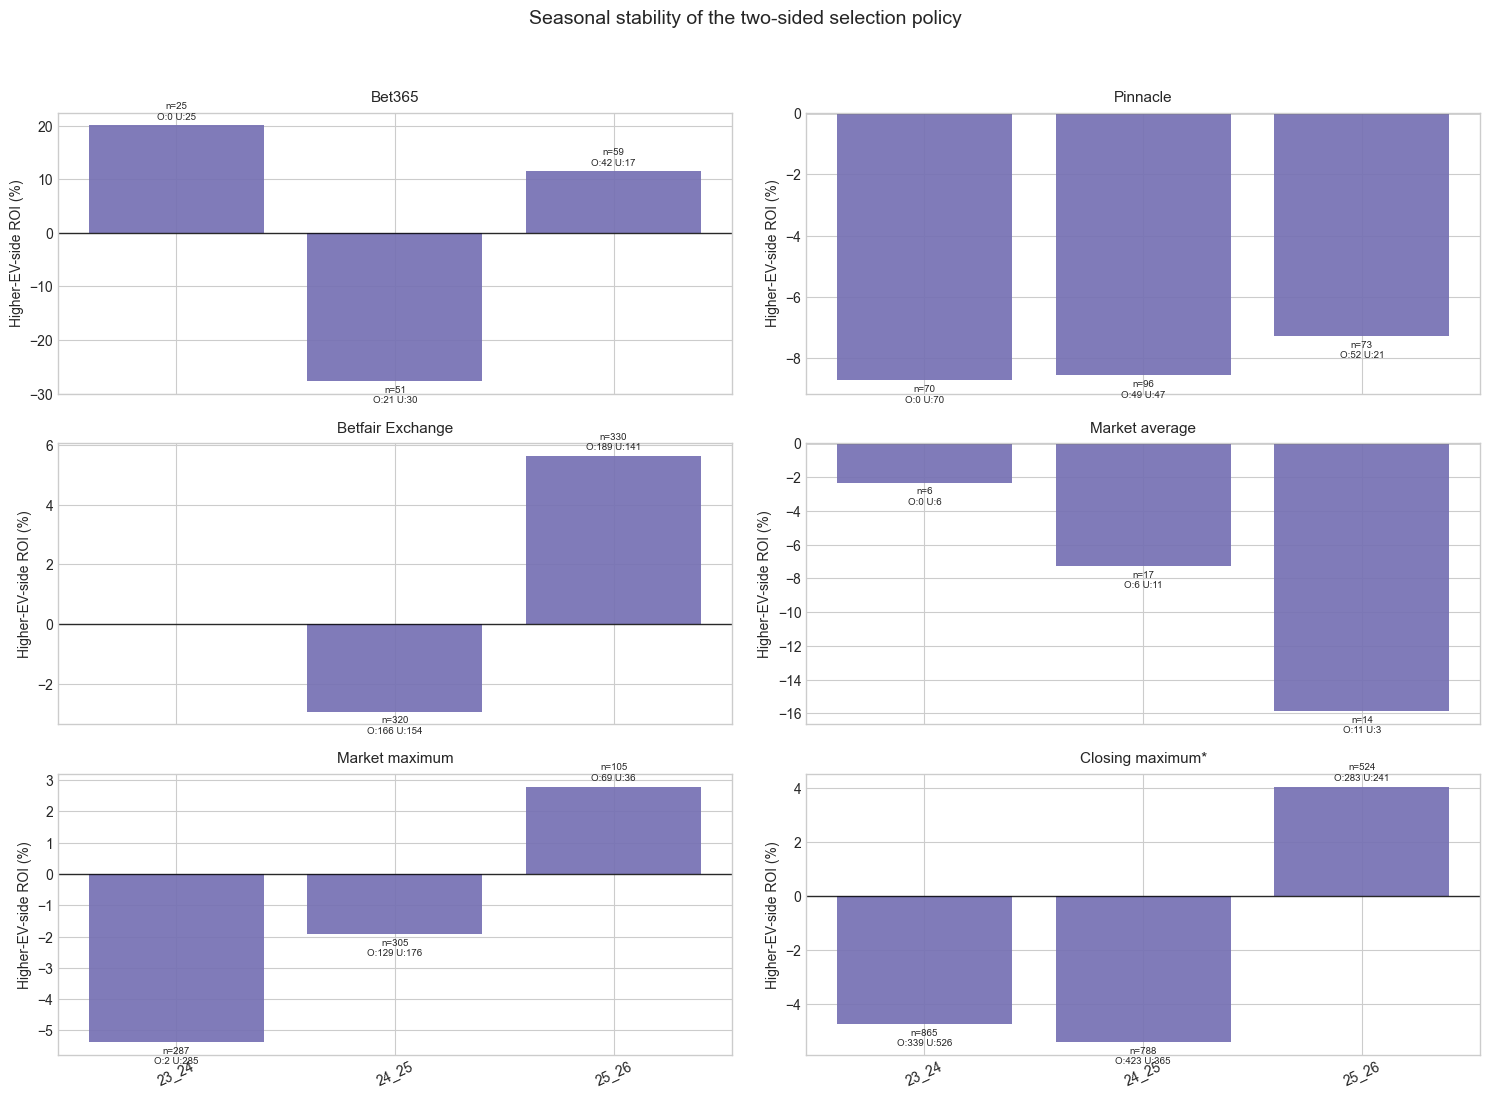

,execution_source,season,bets,wins,win_rate_pct,average_odds,profit_units,roi_pct,roi_95_low_pct,roi_95_high_pct,mean_clv_pct,max_drawdown_units,over,under
0,average_preclosing,23_24,6,2,33.333333,3.023333,-0.14,-2.333333,-123.639934,118.973268,-4.849438,3.00,0,6
1,average_preclosing,24_25,17,8,47.058824,2.011765,-1.24,-7.294118,-56.000032,41.411797,1.333005,5.04,6,11
2,average_preclosing,25_26,14,6,42.857143,1.957143,-2.22,-15.857143,-71.537786,39.823500,-1.882340,4.00,11,3
3,best_closing,23_24,865,361,41.734104,2.446983,-41.11,-4.752601,-12.634198,3.128995,NaN,52.16,339,526
4,best_closing,24_25,788,358,45.431472,2.217081,-42.69,-5.417513,-13.100830,2.265804,NaN,59.44,423,365
5,best_closing,25_26,524,244,46.564885,2.338531,21.24,4.053435,-6.033425,14.140295,NaN,18.52,283,241
6,best_preclosing,23_24,287,128,44.599303,2.275192,-15.43,-5.376307,-18.146686,7.394073,-1.003271,34.19,2,285
7,best_preclosing,24_25,305,158,51.803279,1.981049,-5.87,-1.924590,-12.841989,8.992808,-0.749470,15.08,129,176
8,best_preclosing,25_26,105,50,47.619048,2.208857,2.93,2.790476,-19.494658,25.075610,-0.782432,10.00,69,36
9,bet365,23_24,25,13,52.000000,2.410000,5.02,20.080000,-28.187485,68.347485,-0.630287,3.00,0,25


In [9]:
season_order = sorted(predictions["season"].unique())
season_summary = summarize_two_sided_bets(
    best_side_bets, ["execution_source", "season"]
)
season_mix = (
    best_side_bets.groupby(["execution_source", "season", "bet_side"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)
season_summary = season_summary.merge(
    season_mix, on=["execution_source", "season"], how="left"
)

figure, axes = plt.subplots(3, 2, figsize=(15, 11), sharex=True)
axes = axes.ravel()
for axis, source in zip(axes, SOURCE_ORDER):
    subset = (
        season_summary.loc[season_summary["execution_source"].eq(source)]
        .set_index("season")
        .reindex(season_order)
        .reset_index()
    )
    bars = axis.bar(subset["season"], subset["roi_pct"], color=POLICY_COLORS["best_side"], alpha=0.92)
    add_zero_line(axis)
    labels = []
    for _, row in subset.iterrows():
        if pd.isna(row.get("bets")):
            labels.append("")
        else:
            labels.append(
                f"n={int(row['bets']):,}\nO:{int(row.get('over', 0))} U:{int(row.get('under', 0))}"
            )
    axis.bar_label(bars, labels=labels, padding=3, fontsize=7)
    set_panel_title(axis, source)
    axis.set_ylabel("Higher-EV-side ROI (%)")
    axis.tick_params(axis="x", rotation=25)

figure.suptitle("Seasonal stability of the two-sided selection policy", y=0.995, fontsize=14)
figure.tight_layout(rect=[0, 0, 1, 0.965])
plt.show()

season_summary.sort_values(["execution_source", "season"])

## 8. Conclusions

**Sample size and quote conflicts.**  
The two-sided extension materially increases the number of candidate bets, especially for market maximum and closing maximum prices. Under the higher-EV-side policy, the selected bet counts are: Bet365 135, Pinnacle 239, Betfair Exchange 650, market average 37, market maximum 697, and closing maximum 2,177. Only **2 source-match cases** have both Over and Under qualifying at the same time, so quote conflicts are rare. They should still be treated as quote-quality diagnostics rather than ignored, because both sides qualifying can reflect stale or asynchronously sampled prices.

**Over versus Under.**  
Adding Under 2.5 does **not** create stronger evidence of a tradable edge. The under-only side is mostly negative or statistically weak: market maximum Under loses **-3.46% ROI** on 497 bets, Pinnacle Under loses **-5.89% ROI** on 138 bets, and average pre-closing Under loses **-16.00% ROI** on only 20 bets. Bet365 Under is positive at **+3.99% ROI** on 72 bets and Betfair Exchange Under is positive at **+2.84% ROI** on 295 bets, but their bootstrap intervals are wide and include zero. These positive results are therefore not robust enough to claim an edge.

**Combined higher-EV-side policy.**  
The combined rule does not materially improve the research conclusion. It loses money for Bet365 (**-1.70% ROI**), Pinnacle (**-8.21% ROI**), market average (**-9.73% ROI**), market maximum (**-2.64% ROI**), and closing maximum (**-2.87% ROI**). Betfair Exchange is the only positive combined result at **+1.42% ROI** on 650 bets, but it has negative mean CLV and unstable seasonal performance, so it should be interpreted as weak evidence rather than a discovered strategy.

**Closing-line value.**  
CLV is mostly negative across executable sources. This is important: even where realized ROI is positive, the selected prices generally do not beat the later side-specific closing price. Betfair Exchange has positive realized ROI but mean CLV is negative for both Over (**-0.97%**) and Under (**-1.35%**). That weakens the economic interpretation because a genuine pricing edge should usually show at least neutral-to-positive CLV over a reasonable sample.

**Stability.**  
Performance is not stable across seasons. Bet365 alternates between strongly positive and strongly negative seasons, Betfair Exchange is negative in 2024/25 and positive in 2025/26, and market maximum only turns positive in 2025/26. This pattern is more consistent with noisy realized outcomes than with a persistent edge.

**Overall conclusion.**  
This notebook is useful as a robustness and market-efficiency extension, but it should **not** be presented as evidence of a profitable two-sided betting strategy. Its strongest value for the public project is methodological: it shows that the research does not stop at Over 2.5, tests the symmetric Under side, reports bet counts and CLV, and avoids retrospectively selecting the better historical side. The result strengthens the conservative interpretation of the project: the market-anchored model finds occasional positive realized pockets, but the evidence is not robust after uncertainty, CLV, execution realism, and seasonal stability are considered.

**Publication decision.**  
I would publish this notebook as a secondary robustness notebook, not as the headline notebook. It makes the project look more mature because it directly addresses the natural critique that a market-efficiency study should test both Over and Under. The notebook should be framed as **?two-sided robustness analysis?** rather than **?new strategy discovery?**.
